# Praktikum 1 - The Knight's Tour

#### 1. Algoritma Code (Heuristik Warnsdorff)

In [1]:
# Ukuran Papan (8x8)
N = 8

# Gerakan Kuda (L-shape): (x, y)
moves = [
    (1, 2), (1, -2), (-1, 2), (-1, -2),
    (2, 1), (2, -1), (-2, 1), (-2, -1)
]

def is_valid(x, y, board):
    """Cek apakah langkah masih di dalam papan dan belum dikunjungi"""
    return 0 <= x < N and 0 <= y < N and board[y][x] == -1

def get_degree(x, y, board):
    """
    Heuristik Warnsdorff:
    Hitung ada berapa langkah selanjutnya yang mungkin dari posisi (x,y).
    Kita akan memprioritaskan kotak yang punya pilihan paling sedikit.
    """
    count = 0
    for dx, dy in moves:
        if is_valid(x + dx, y + dy, board):
            count += 1
    return count

def solve_knights_tour(start_x, start_y):
    # Inisialisasi papan dengan -1 (artinya belum dikunjungi)
    board = [[-1 for _ in range(N)] for _ in range(N)]
    
    # Kuda mulai di posisi awal (langkah ke-0)
    board[start_y][start_x] = 0
    
    # Simpan urutan koordinat untuk visualisasi nanti
    path = [(start_x, start_y)]
    
    # Mulai langkah dari 1 sampai 63
    curr_x, curr_y = start_x, start_y
    for step in range(1, N*N):
        # Cari semua langkah yang mungkin dari posisi sekarang
        possible_moves = []
        for dx, dy in moves:
            nx, ny = curr_x + dx, curr_y + dy
            if is_valid(nx, ny, board):
                # Hitung degree (prioritas) langkah tersebut
                priority = get_degree(nx, ny, board)
                possible_moves.append((priority, nx, ny))
        
        # Jika tidak ada langkah lagi tapi belum selesai, berarti gagal (buntu)
        if not possible_moves:
            return None 
        
        # Urutkan berdasarkan priority terendah (Warnsdorff's Rule)
        possible_moves.sort(key=lambda x: x[0])
        
        # Pilih langkah terbaik
        _, next_x, next_y = possible_moves[0]
        
        # Update papan dan posisi
        board[next_y][next_x] = step
        curr_x, curr_y = next_x, next_y
        path.append((curr_x, curr_y))
        
    return path

print("Fungsi Knight's Tour siap digunakan!")

Fungsi Knight's Tour siap digunakan!


#### 2. Visualisasi Code

In [2]:
import matplotlib.pyplot as plt

def draw_tour(path, title="Knight's Tour"):
    plt.figure(figsize=(8, 8))
    ax = plt.gca()
    
    # 1. Gambar Papan Catur
    for x in range(N):
        for y in range(N):
            # Warna selang-seling (putih & abu-abu)
            color = 'white' if (x + y) % 2 == 0 else 'lightgray'
            rect = plt.Rectangle((x, y), 1, 1, facecolor=color)
            ax.add_patch(rect)
            
    # 2. Gambar Jalur Kuda
    # Pisahkan koordinat X dan Y dari path
    x_coords = [p[0] + 0.5 for p in path] # +0.5 agar titiknya di tengah kotak
    y_coords = [p[1] + 0.5 for p in path]
    
    # Gambar garis penghubung (Route)
    plt.plot(x_coords, y_coords, color='black', linewidth=1.5, marker='o', markersize=5)
    
    # Tandai Awal (Hijau) dan Akhir (Merah)
    plt.plot(x_coords[0], y_coords[0], 'go', markersize=15, label='Start') # Start
    plt.plot(x_coords[-1], y_coords[-1], 'ro', markersize=15, label='End') # End
    
    # Panah arah (opsional, agar terlihat alurnya)
    # Kita gambar panah di beberapa titik saja agar tidak semrawut
    for i in range(0, len(path)-1, 1):
        plt.arrow(x_coords[i], y_coords[i], 
                  (x_coords[i+1]-x_coords[i])*0.5, (y_coords[i+1]-y_coords[i])*0.5, 
                  head_width=0.1, color='black')

    # Setting Tampilan
    plt.xlim(0, N)
    plt.ylim(0, N)
    plt.xticks(range(N))
    plt.yticks(range(N))
    plt.grid(True, color='black', linewidth=0.5)
    plt.title(title, fontsize=15)
    plt.legend()
    plt.axis('off') # Matikan axis angka jika ingin bersih
    plt.show()

print("Fungsi Visualisasi siap!")

Fungsi Visualisasi siap!


#### 3. Eksekusi Code

Sukses! Ditemukan jalur dengan 64 langkah.
Tipe: Open Tour (Lintasan)


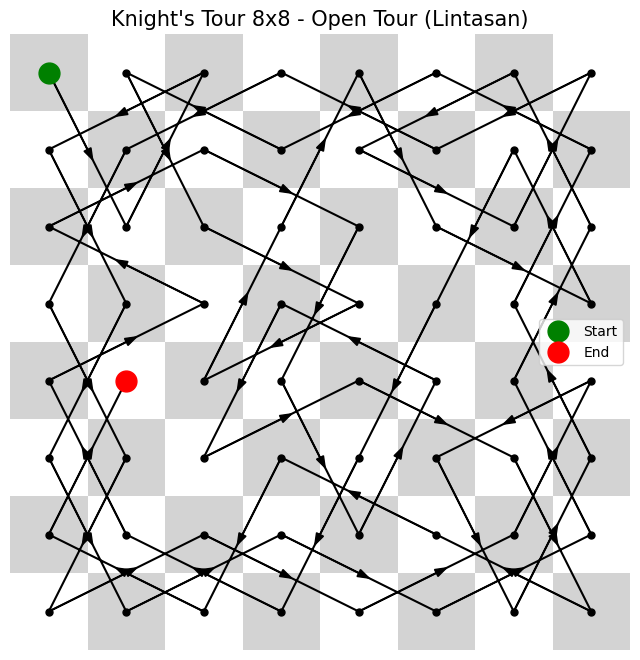

In [5]:
# Tentukan posisi awal (0-7). Misal mulai di pojok kiri bawah (0,0)
start_x = 0
start_y = 7

# Cari Jalur
jalur = solve_knights_tour(start_x, start_y)

if jalur:
    print(f"Sukses! Ditemukan jalur dengan {len(jalur)} langkah.")
    
    # Cek apakah Open atau Closed Tour
    sx, sy = jalur[0]
    ex, ey = jalur[-1]
    
    # Cek apakah titik akhir bisa menyerang titik awal
    is_closed = False
    for dx, dy in moves:
        if ex + dx == sx and ey + dy == sy:
            is_closed = True
            break
            
    status = "Closed Tour (Sirkuit)" if is_closed else "Open Tour (Lintasan)"
    print(f"Tipe: {status}")
    
    # Gambar hasilnya
    draw_tour(jalur, title=f"Knight's Tour 8x8 - {status}")
else:
    print("Maaf, gagal menemukan jalur dari titik start ini.")